In [56]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn import linear_model
from sklearn.linear_model import SGDRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

## Load Excel File

In [58]:
df = pd.read_excel('AmesHousing.xlsx')
# Amount of data row and column
print('rows and columns',df.shape)
df.dtypes

rows and columns (2930, 12)


ID                 int64
SalePrice          int64
Garage               str
Overall Qual       int64
Gr Liv Area        int64
Total Bsmt SF    float64
Lot Area           int64
Year Built         int64
Full Bath          int64
Bedroom AbvGr      int64
Neighborhood         str
House Style          str
dtype: object

## One-hot encoding ( Neighborhood, HouseStyle)

In [59]:
# One-hot encoding
df_hot_reloaded = pd.get_dummies(df, columns=['House Style', 'Neighborhood'], drop_first=True)
# df_hot_reloaded  
df_hot_reloaded.dtypes

ID                        int64
SalePrice                 int64
Garage                      str
Overall Qual              int64
Gr Liv Area               int64
Total Bsmt SF           float64
Lot Area                  int64
Year Built                int64
Full Bath                 int64
Bedroom AbvGr             int64
House Style_1.5Unf         bool
House Style_1Story         bool
House Style_2.5Fin         bool
House Style_2.5Unf         bool
House Style_2Story         bool
House Style_SFoyer         bool
House Style_SLvl           bool
Neighborhood_Blueste       bool
Neighborhood_BrDale        bool
Neighborhood_BrkSide       bool
Neighborhood_ClearCr       bool
Neighborhood_CollgCr       bool
Neighborhood_Crawfor       bool
Neighborhood_Edwards       bool
Neighborhood_Gilbert       bool
Neighborhood_Greens        bool
Neighborhood_GrnHill       bool
Neighborhood_IDOTRR        bool
Neighborhood_Landmrk       bool
Neighborhood_MeadowV       bool
Neighborhood_Mitchel       bool
Neighbor

# Define Datasets X (features) - Y (target) 

In [86]:

## Defined Targets and Features
kyran_ds = [
    ('Full Bath', ['SalePrice', 'Lot Area'] + list(df_hot_reloaded.filter(like='House Style').columns)),
    ('SalePrice', ['Lot Area', 'Year Built'] + list(df_hot_reloaded.filter(like='Neighborhood').columns)),
]

roody_ds = [
    ('SalePrice', ['Year Built', 'Full Bath'] + list(df_hot_reloaded.filter(like='House Style').columns)),
    ('SalePrice', ['Year Built', 'Lot Area'] + list(df_hot_reloaded.filter(like='Neighborhood').columns)),
    ('SalePrice', ['Year Built', 'Bedroom AbvGr'] + list(df_hot_reloaded.filter(like='Neighborhood').columns)),
    ('Full Bath', ['Year Built', 'Bedroom AbvGr'] + list(df_hot_reloaded.filter(like='Neighborhood').columns)),
    ('Full Bath', ['Year Built', 'Bedroom AbvGr'] + list(df_hot_reloaded.filter(like='House Style').columns)),

]

# Combine the datasets
datasets = kyran_ds + roody_ds

# Print columns target and features
for target, features in datasets:
    print('Target:', target)
    print('Features:', features)


Target: Full Bath
Features: ['SalePrice', 'Lot Area', 'House Style_1.5Unf', 'House Style_1Story', 'House Style_2.5Fin', 'House Style_2.5Unf', 'House Style_2Story', 'House Style_SFoyer', 'House Style_SLvl']
Target: SalePrice
Features: ['Lot Area', 'Year Built', 'Neighborhood_Blueste', 'Neighborhood_BrDale', 'Neighborhood_BrkSide', 'Neighborhood_ClearCr', 'Neighborhood_CollgCr', 'Neighborhood_Crawfor', 'Neighborhood_Edwards', 'Neighborhood_Gilbert', 'Neighborhood_Greens', 'Neighborhood_GrnHill', 'Neighborhood_IDOTRR', 'Neighborhood_Landmrk', 'Neighborhood_MeadowV', 'Neighborhood_Mitchel', 'Neighborhood_NAmes', 'Neighborhood_NPkVill', 'Neighborhood_NWAmes', 'Neighborhood_NoRidge', 'Neighborhood_NridgHt', 'Neighborhood_OldTown', 'Neighborhood_SWISU', 'Neighborhood_Sawyer', 'Neighborhood_SawyerW', 'Neighborhood_Somerst', 'Neighborhood_StoneBr', 'Neighborhood_Timber', 'Neighborhood_Veenker']
Target: SalePrice
Features: ['Year Built', 'Full Bath', 'House Style_1.5Unf', 'House Style_1Story', '

## horizontaal en verticaal snijden van tabel (Train-Test split) 
## Create Linear Model

In [108]:
results = []

for dataset_index, (target, features) in enumerate(datasets, start=1):
    # Define X and Y
    X = df_hot_reloaded[features]
    Y = df_hot_reloaded[target]

    # Train-test split
    X_train, X_test, Y_train, Y_test = train_test_split(
        X, Y,
        test_size=0.15,
        random_state=42
    )

    # Train model with Hyperparameters 
    model = LinearRegression(fit_intercept=True, positive=True)
    model.fit(X_train, Y_train)

    # Predict
    Y_pred = pd.Series(model.predict(X_test), index=Y_test.index, name="Predicted")

    if target == "Full Bath":
        Y_pred = Y_pred.round().astype(int)

    # Evaluate
    mse = mean_squared_error(Y_test, Y_pred)
    mae = mean_absolute_error(Y_test, Y_pred)
    r2_score = model.score(X_test, Y_test)

    # Store everything needed for later analysis and plotting
    results.append({
        "dataset_index": dataset_index,
        "target": target,
        "features": features,
        "model": model,
        "split": {
            "X_train": X_train,
            "X_test": X_test,
            "Y_train": Y_train,
            "Y_test": Y_test,
        },
        "Y_pred": Y_pred,
        "metrics": {
            "mse": mse,
            "mae": mae,
            "r2_score": r2_score,
        },
    })

# Flat summary table for quick comparison
results_df = pd.DataFrame([
    {
        "dataset_index": run["dataset_index"],
        "target": run["target"],
        "features": ", ".join(run["features"]),
        "mse": run["metrics"]["mse"],
        "mae": run["metrics"]["mae"],
        "r2_score": run["metrics"]["r2_score"],
    }
    for run in results
]).sort_values("mse").reset_index(drop=True)

results_df

,dataset_index,target,features,mse,mae,r2_score
0,6,Full Bath,"Year Built, Bedroom AbvGr, Neighborhood_Bluest...",1.840909e-01,0.184091,0.502071
1,7,Full Bath,"Year Built, Bedroom AbvGr, House Style_1.5Unf,...",2.340909e-01,0.229545,0.413717
2,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House...",2.568182e-01,0.252273,0.358785
3,4,SalePrice,"Year Built, Lot Area, Neighborhood_Blueste, Ne...",2.544069e+09,34470.620553,0.668850
4,2,SalePrice,"Lot Area, Year Built, Neighborhood_Blueste, Ne...",2.544069e+09,34470.620553,0.668850
5,5,SalePrice,"Year Built, Bedroom AbvGr, Neighborhood_Bluest...",2.729620e+09,35018.351116,0.644697
6,3,SalePrice,"Year Built, Full Bath, House Style_1.5Unf, Hou...",4.139059e+09,44032.949476,0.461237


## Merge prediction with actual target (all runs)

In [101]:
prediction_frames = []

for run in results:
    Y_test = run["split"]["Y_test"].reset_index(drop=True)
    Y_pred = pd.Series(run["Y_pred"], name="Predicted").reset_index(drop=True)

    merged = pd.DataFrame({
        "Actual": Y_test,
        "Predicted": Y_pred,
    })

    if run["target"] == "Full Bath":
        merged["Actual"] = merged["Actual"].astype(int)
        merged["Predicted"] = merged["Predicted"].astype(int)

    merged["dataset_index"] = run["dataset_index"]
    merged["target"] = run["target"]
    merged["features"] = ", ".join(run["features"][:4]) + ("..." if len(run["features"]) > 4 else "")

    prediction_frames.append(merged)

predictions_all = pd.concat(prediction_frames, ignore_index=True)
predictions_all.head(10)

,Actual,Predicted,dataset_index,target,features
0,1,2.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
1,1,2.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
2,2,2.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
3,1,1.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
4,1,1.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
5,2,1.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
6,1,2.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
7,2,2.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
8,1,1.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."
9,2,3.0,1,Full Bath,"SalePrice, Lot Area, House Style_1.5Unf, House..."


## Create scatter plots per run

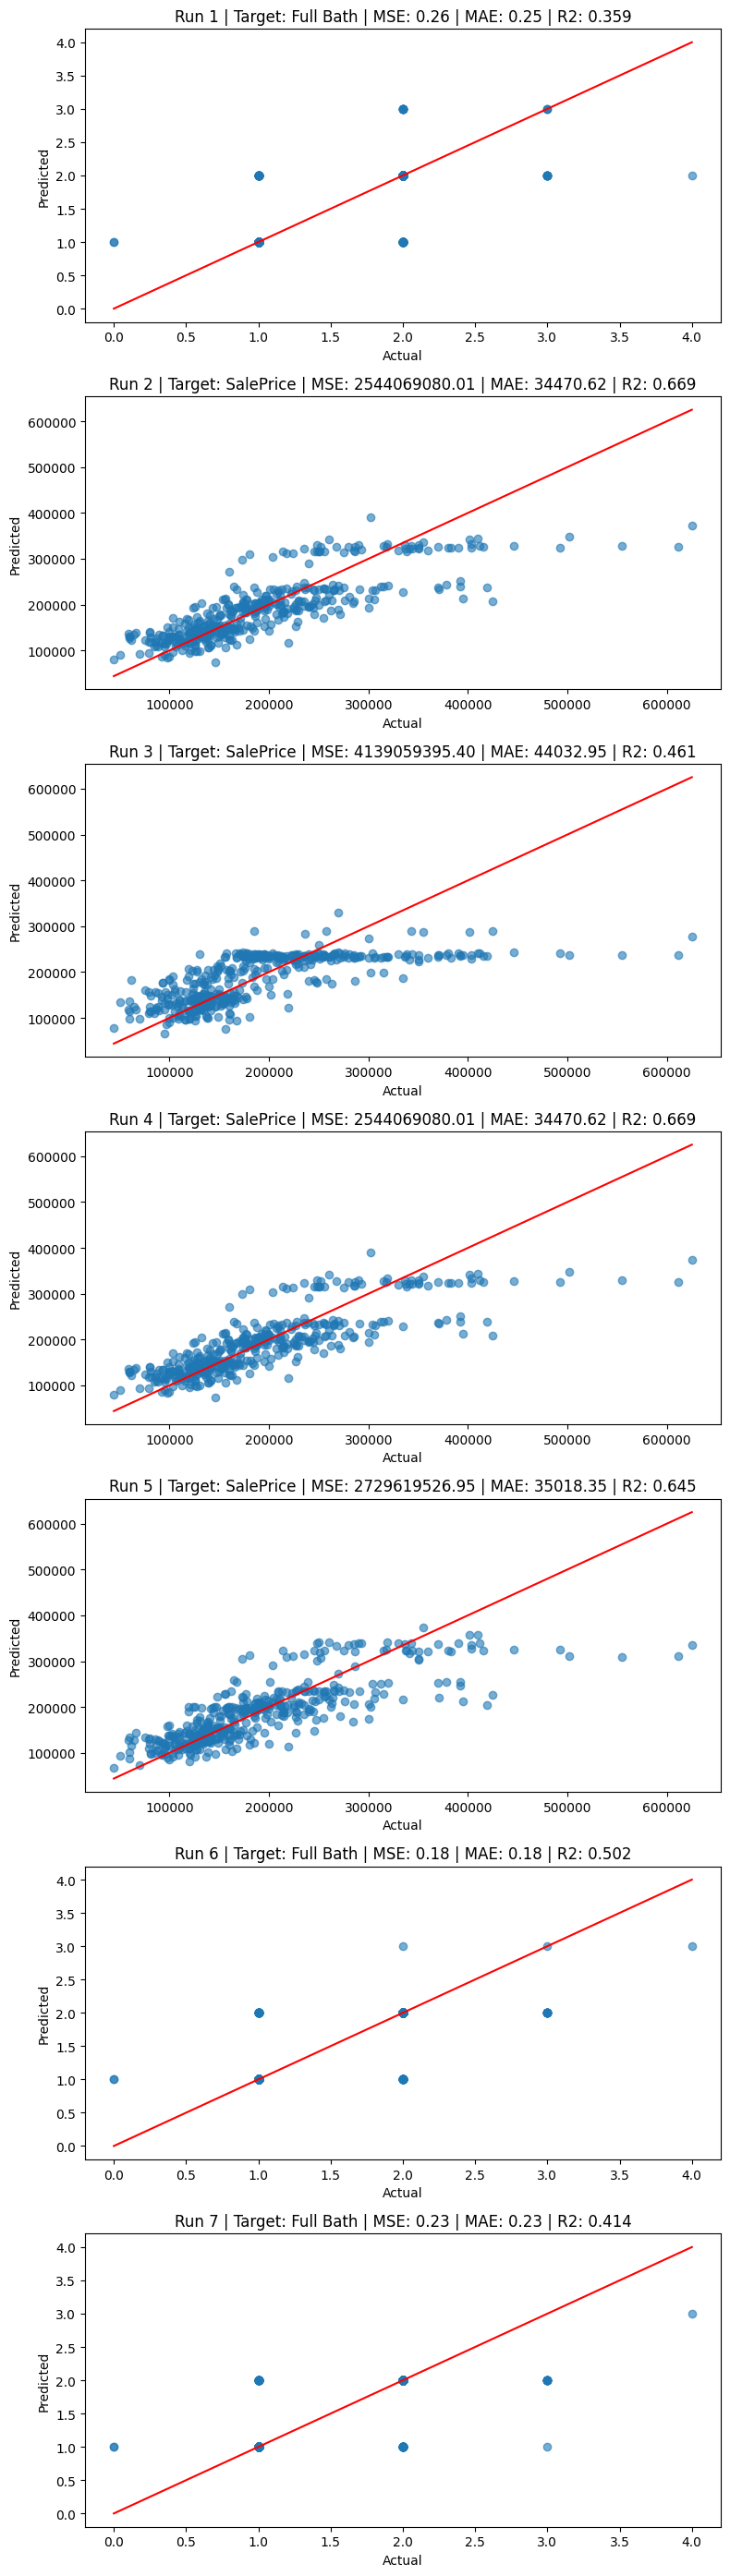

In [102]:
# Build one subplot per experiment run
num_runs = len(results)
fig, axes = plt.subplots(
    nrows=num_runs,
    ncols=1,
    figsize=(8, max(4, 4 * num_runs))
)

# Keep axes iterable when there is only one run
if num_runs == 1:
    axes = [axes]

for ax, run in zip(axes, results):
    # Select merged rows that belong to this dataset configuration
    plot_df = predictions_all[predictions_all["dataset_index"] == run["dataset_index"]]

    # Scatter: actual values vs model predictions
    ax.scatter(plot_df["Actual"], plot_df["Predicted"], alpha=0.6)

    # Reference diagonal (perfect prediction line: y = x)
    min_value = min(plot_df["Actual"].min(), plot_df["Predicted"].min())
    max_value = max(plot_df["Actual"].max(), plot_df["Predicted"].max())
    ax.plot([min_value, max_value], [min_value, max_value], color="red")

    # Show run metadata and quality metrics in the title
    metrics = run["metrics"]
    ax.set_title(
        f"Run {run['dataset_index']} | Target: {run['target']} | "
        f"MSE: {metrics['mse']:.2f} | MAE: {metrics['mae']:.2f} | R2: {metrics['r2_score']:.3f}"
    )
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")

# Prevent subplot overlap and render figure
plt.tight_layout()
plt.show()

# Experiment 7: SGDRegressor op Second Prediction (SalePrice) - lr=0.00005, epochs=4000

In [105]:
# Train SGD model with custom parameters on second SalePrice run
saleprice_runs = [run for run in results if run["target"] == "SalePrice"]

if len(saleprice_runs) == 0:
    raise ValueError("No SalePrice run found in results.")

# Pick the second SalePrice configuration when available
sgd_base_run = saleprice_runs[1] if len(saleprice_runs) > 1 else saleprice_runs[0]
X_train_sgd = sgd_base_run["split"]["X_train"]
X_test_sgd = sgd_base_run["split"]["X_test"]
Y_train_sgd = sgd_base_run["split"]["Y_train"]
Y_test_sgd = sgd_base_run["split"]["Y_test"]

sgd_model7 = make_pipeline(
    StandardScaler(),
    SGDRegressor(learning_rate="constant", eta0=0.00005, max_iter=4000, random_state=42)
 )
sgd_model7.fit(X_train_sgd, Y_train_sgd)

# Make predictions
Y_pred_sgd7 = sgd_model7.predict(X_test_sgd)

# Create DataFrame for predictions
prediction_df_sgd7 = pd.DataFrame({
    "SalePrice": Y_test_sgd.values,
    "Predicted SalePrice": Y_pred_sgd7
})

prediction_df_sgd7.head(10)

,SalePrice,Predicted SalePrice
0,161000,106931.647914
1,116000,158603.724262
2,196500,239066.535633
3,123600,176534.930547
4,126000,101775.330724
5,174190,236109.030203
6,200000,169938.495268
7,148500,209382.576880
8,88750,123763.448319
9,409900,243464.159152


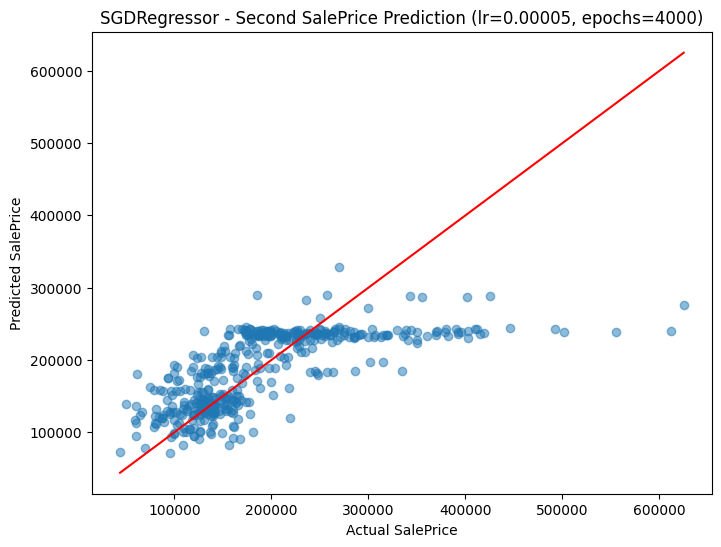

MSE: 4099976060.7782025
MAE: 43668.50841194808
R² Score: 0.46632383103994357


In [106]:
# Visualization
plt.figure(figsize=(8, 6))
plt.scatter(prediction_df_sgd7["SalePrice"], prediction_df_sgd7["Predicted SalePrice"], alpha=0.5)

# Plot perfect prediction line
min_value_sgd7 = min(prediction_df_sgd7["SalePrice"].min(), prediction_df_sgd7["Predicted SalePrice"].min())
max_value_sgd7 = max(prediction_df_sgd7["SalePrice"].max(), prediction_df_sgd7["Predicted SalePrice"].max())
plt.plot([min_value_sgd7, max_value_sgd7], [min_value_sgd7, max_value_sgd7], color="red")

plt.xlabel("Actual SalePrice")
plt.ylabel("Predicted SalePrice")
plt.title("SGDRegressor - Second SalePrice Prediction (lr=0.00005, epochs=4000)")
plt.show()

# Metrics
mse_sgd7 = mean_squared_error(prediction_df_sgd7["SalePrice"], prediction_df_sgd7["Predicted SalePrice"])
mae_sgd7 = mean_absolute_error(prediction_df_sgd7["SalePrice"], prediction_df_sgd7["Predicted SalePrice"])
r2_sgd7 = sgd_model7.score(X_test_sgd, Y_test_sgd)

print(f"MSE: {mse_sgd7}")
print(f"MAE: {mae_sgd7}")
print(f"R² Score: {r2_sgd7}")